In [1]:
import json
import pandas as pd

xs = [0, 5, 10, 20, 30, 40, 50]

def parse_duration(lines: list) -> float:
    durations = []
    for line in lines:
        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            continue
        duration = row.get("podStartE2EDuration")
        if duration is None:
            continue
        durations.append(duration)
    
    return pd.to_timedelta(durations)

experiments = [
    {
        "name": "nocgroup-fifo-k90-c99",
        "filename_tmpl": "logs/log_{0}_20r-nocgroup-fifo-k90-c99.json"
    },
    {
        "name": "nocgroup-nort",
        "filename_tmpl": "logs/log_{0}_20r-nocgroup-nort.json"
    },
    {
        "name": "cgroup-nort",
        "filename_tmpl": "logs/log_{0}_20r-cgroup-nort.json"
    },
    {
        "name": "cgroup-fifo-k90-c99",
        "filename_tmpl": "logs/log_{0}_20r-cgroup-fifo-k90-c99.json"
    },
    {
        "name": "2cgroup-4cpu-fifo-k99-c99",
        "filename_tmpl": "logs/log_{0}_20r-2cgroup-fifo-k99-c99.json"
    },
    {
        "name": "2cgroup-8cpu-fifo-k99-c99",
        "filename_tmpl": "logs/log_{0}_20r-2cgroup-8cpu-fifo-k99-c99.json"
    },
    {
        "name": "nocgroup-4cpu-fifo-k99-c99",
        "filename_tmpl": "logs/log_{0}_20r-nocgroup-2cpu-fifo-k99-c99.json"
    },
    {
        "name": "nocgroup-8cpu-fifo-k99-c99",
        "filename_tmpl": "logs/log_{0}_20r-nocgroup-8cpu-fifo-k99-c99.json"
    },
     {
        "name": "nocgroup-2-isolcpus-fifo-k99-c99",
        "filename_tmpl": "logs/log_{0}_20r-nocgroup-isolcpus-2cpu-fifo-k99-c99.json"
    },
]

print(len(experiments), "experiments")
results = {}
for (i, experiment) in enumerate(experiments):
    name = experiment["name"]
    results[name] = []
    for x in xs[1:]:
        fname = experiment["filename_tmpl"].format(x)
        with open(fname, "r") as f:
            lines = f.readlines()
        durations = parse_duration(lines)
        results[name].append(durations)
        print("experiment", name, x, "pods", "mean", durations.mean().total_seconds(), "seconds")

9 experiments
experiment nocgroup-fifo-k90-c99 5 pods mean 2.081957 seconds
experiment nocgroup-fifo-k90-c99 10 pods mean 1.901356 seconds
experiment nocgroup-fifo-k90-c99 20 pods mean 2.315315 seconds
experiment nocgroup-fifo-k90-c99 30 pods mean 2.824188 seconds
experiment nocgroup-fifo-k90-c99 40 pods mean 3.24914 seconds
experiment nocgroup-fifo-k90-c99 50 pods mean 3.9818540000000002 seconds
experiment nocgroup-nort 5 pods mean 1.918833 seconds
experiment nocgroup-nort 10 pods mean 1.805782 seconds
experiment nocgroup-nort 20 pods mean 2.07465 seconds
experiment nocgroup-nort 30 pods mean 3.154149 seconds
experiment nocgroup-nort 40 pods mean 3.196517 seconds
experiment nocgroup-nort 50 pods mean 3.6191079999999998 seconds
experiment cgroup-nort 5 pods mean 2.058934 seconds
experiment cgroup-nort 10 pods mean 2.350922 seconds
experiment cgroup-nort 20 pods mean 3.322704 seconds
experiment cgroup-nort 30 pods mean 5.095607 seconds
experiment cgroup-nort 40 pods mean 5.902986 second

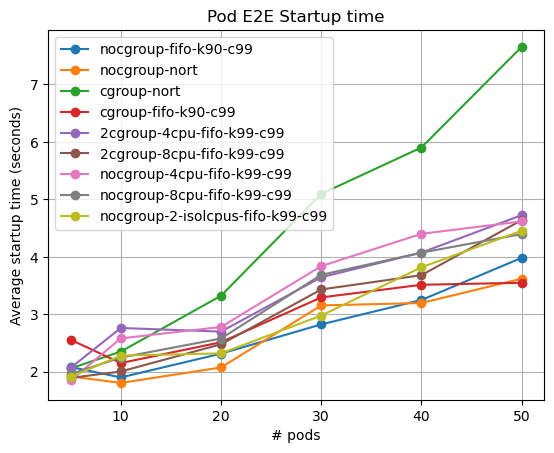

In [153]:
import pandas as pd
import matplotlib.pyplot as plt

plt.title("Pod E2E Startup time")
plt.xlabel("# pods")
plt.ylabel("Average startup time (seconds)")

for (name, data) in results.items():
    plt.plot(xs[1:], [d.mean().total_seconds() for d in data], label=name, marker="o")
    
plt.legend()
plt.grid(True)
plt.savefig("build/average.pdf")
plt.savefig("build/average.png")
plt.savefig("build/average.svg")

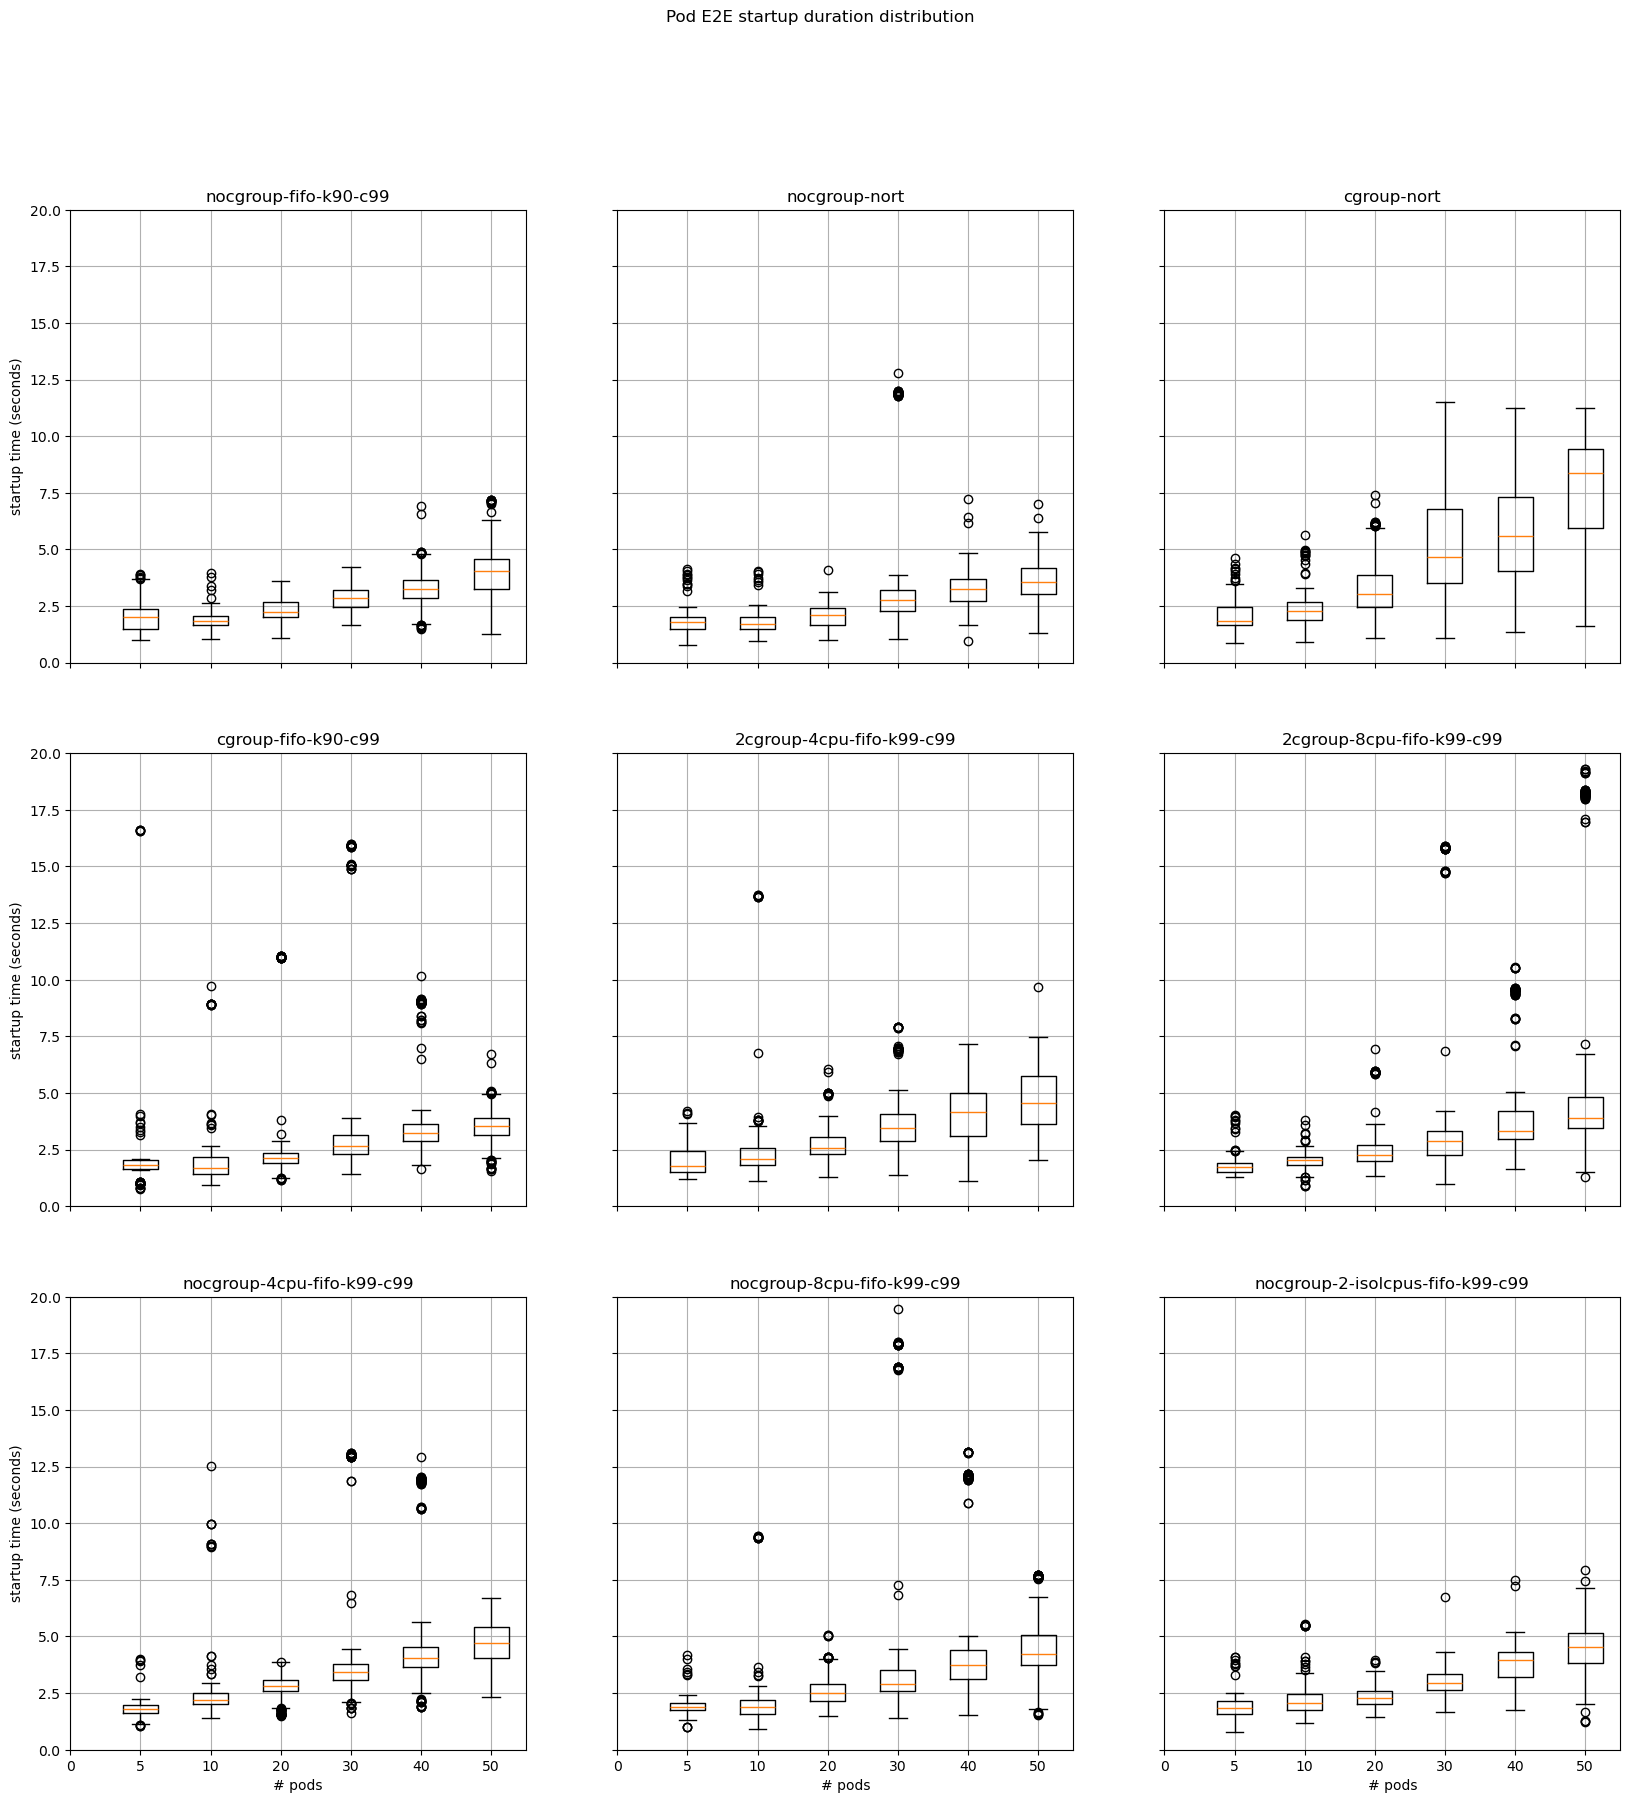

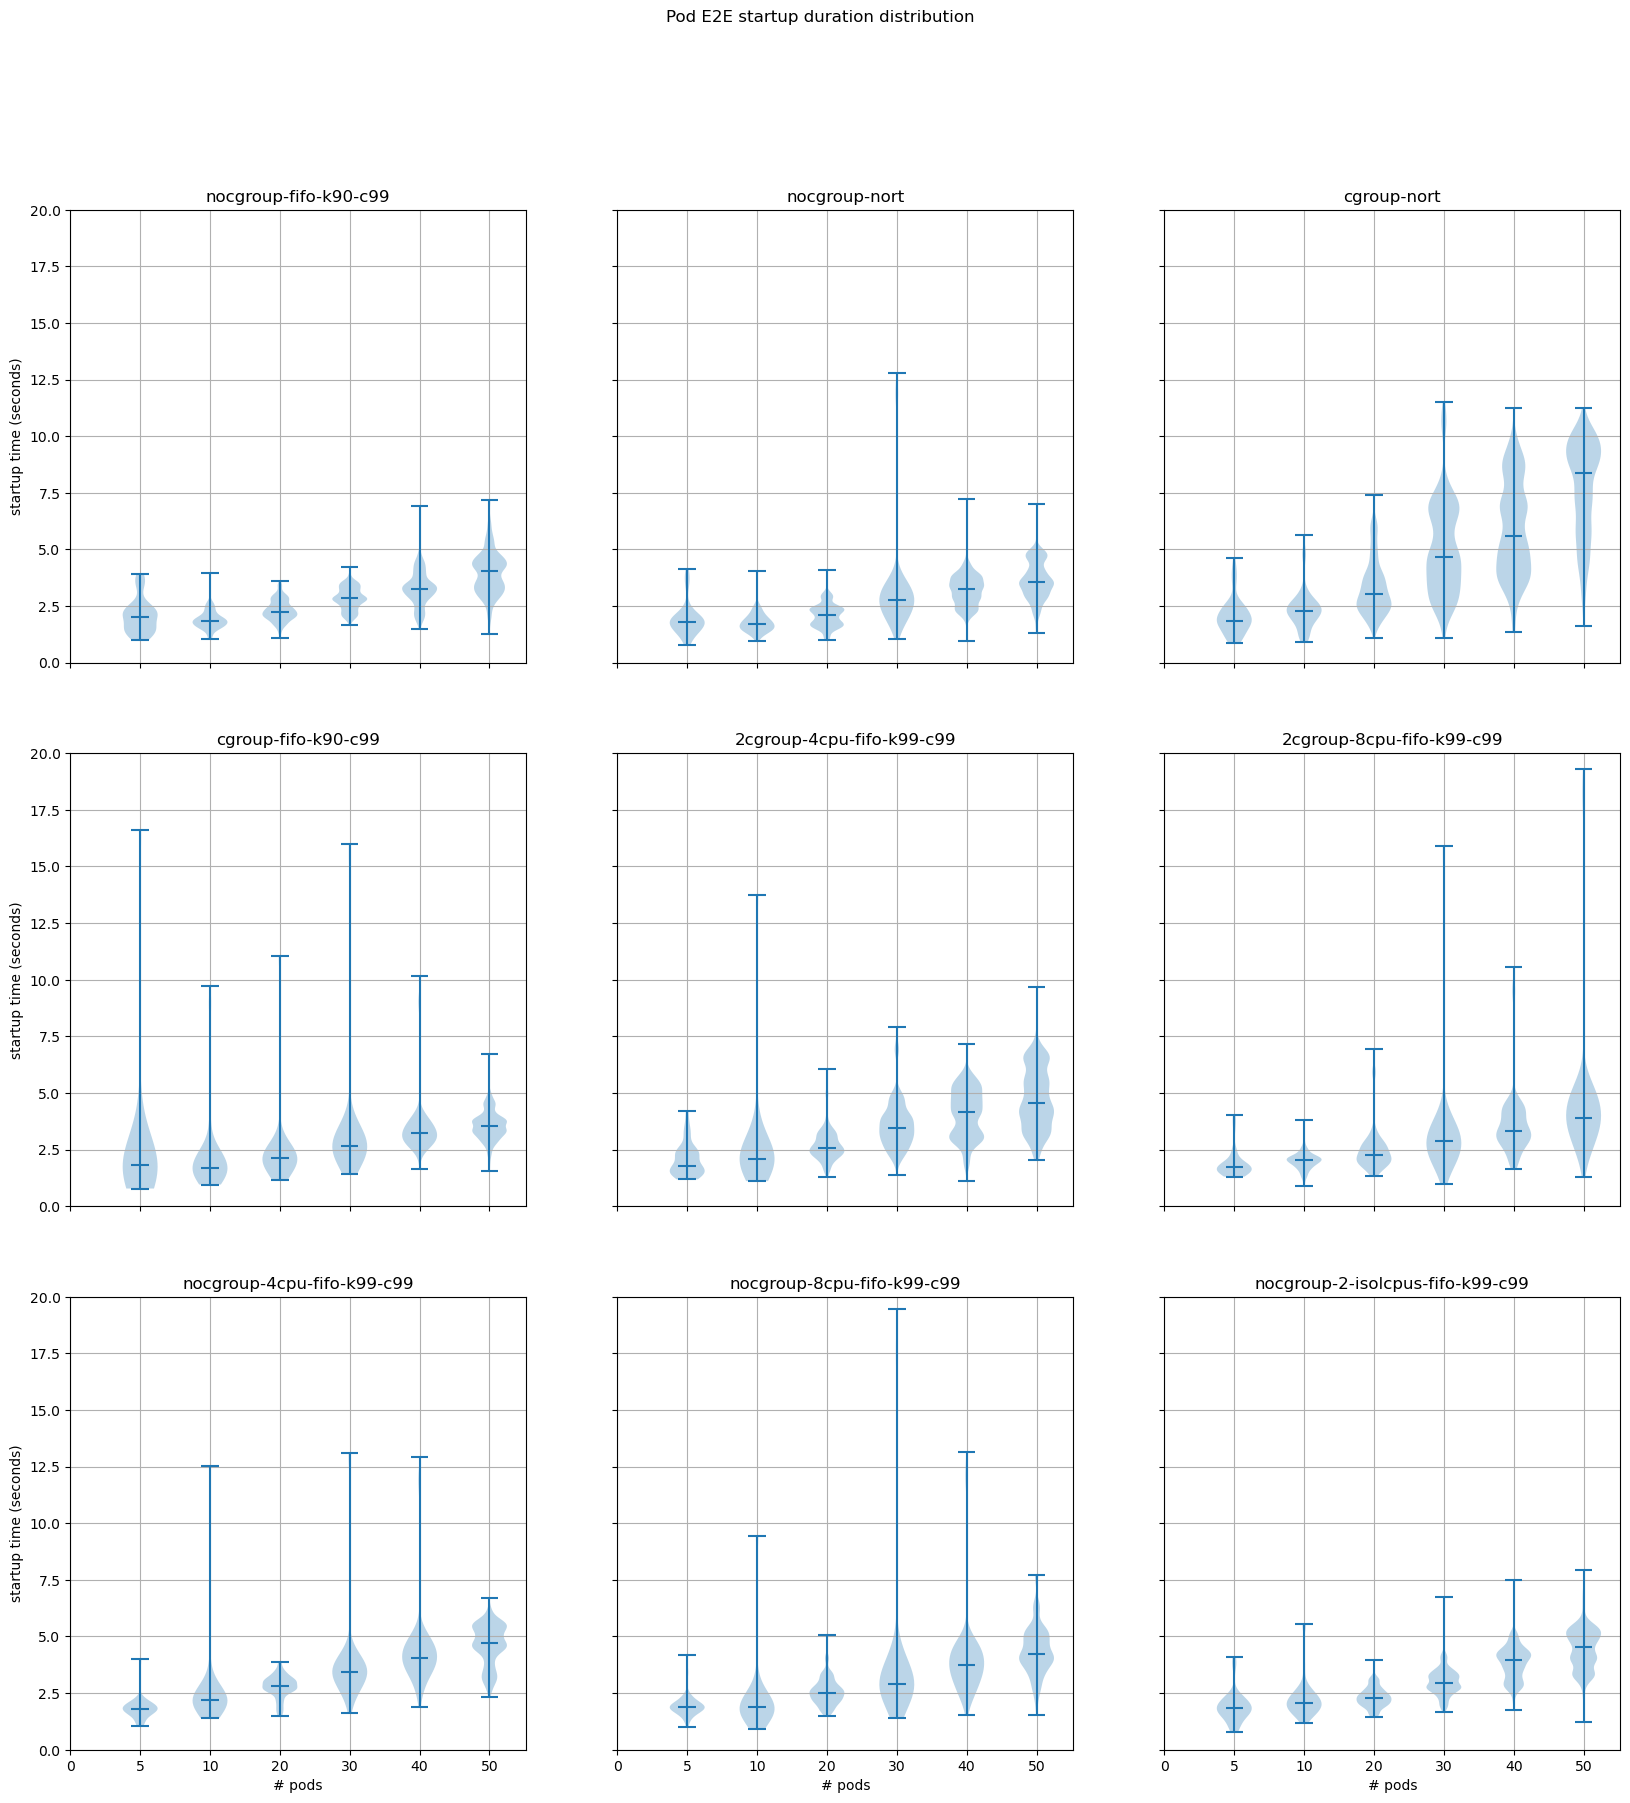

In [2]:
import os
import matplotlib.pyplot as plt

from pathlib import Path

rows = 3
cols = 3

def boxplot_all_quick(odir: str) -> None:
    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Pod E2E startup duration distribution")
    axs = fig.subplots(rows, cols)

    for i in range(rows):
        for j in range(cols):
            k = i*cols+j
            ax = axs[i, j]
            experiment = experiments[k]["name"]
            ax.boxplot([d.total_seconds() for d in results[experiment]])
            ax.set_title(experiment)
            ax.set_xticks(range(len(xs)))
            ax.grid(True)
            ax.set_xticklabels(xs)
            ax.set_ylim([0, 20])

    for ax in axs.flat:
        ax.set(xlabel='# pods', ylabel='startup time (seconds)')
    
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
        
    if odir is not None:
        p = os.path.join(odir, "box.pdf")
        fig.savefig(p)
        p = os.path.join(odir, "box.png")
        fig.savefig(p)
        p = os.path.join(odir, "box.svg")
        fig.savefig(p)


def boxplot_single(odir: str) -> None:
    for experiment in experiments:
        data = [d.total_seconds() for d in results[experiment["name"]]]
        title = experiment["name"]
        ax = plt.gca()
        plt.boxplot(data)
        plt.title(title)
        plt.xticks(range(len(xs)), labels=xs)
        plt.xlabel("# pods")
        plt.ylabel("seconds")
        ax.set_ylim([0, 20])
        plt.grid(True)
        if odir is not None:
            p = os.path.join(odir, f"{title.lower()}.box.pdf")
            plt.savefig(p)
            p = os.path.join(odir, f"{title.lower()}.box.png")
            plt.savefig(p)
            p = os.path.join(odir, f"{title.lower()}.box.svg")
            plt.savefig(p)
            plt.close()

def violinplot_single(odir: str) -> None:
    for experiment in experiments:
        data = [d.total_seconds() for d in results[experiment["name"]]]
        title = experiment["name"]
        ax = plt.gca()
        plt.violinplot(data)
        plt.title(title)
        plt.xticks(range(len(xs)), labels=xs)
        plt.xlabel("# pods")
        plt.ylabel("seconds")
        plt.grid(True)
        ax.set_ylim([0, 20])
        if odir is not None:
            p = os.path.join(odir, f"{title.lower()}.violin.pdf")
            plt.savefig(p)
            p = os.path.join(odir, f"{title.lower()}.violin.png")
            plt.savefig(p)
            p = os.path.join(odir, f"{title.lower()}.violin.svg")
            plt.savefig(p)
            plt.close()

def violinplot_all_quick(odir: str) -> None:
    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Pod E2E startup duration distribution")

    axs = fig.subplots(rows, cols)
    
    for i in range(rows):
        for j in range(cols):
            k = i*cols+j
            ax = axs[i, j]
            experiment = experiments[k]["name"]
            ax.violinplot([d.total_seconds() for d in results[experiment]], showmedians=True)
            ax.set_title(experiment)
            ax.set_xticks(range(len(xs)))
            ax.grid(True)
            ax.set_xticklabels(xs)
            ax.set_ylim([0, 20])
    
    for ax in axs.flat:
        ax.set(xlabel='# pods', ylabel='startup time (seconds)')
    
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()

    if odir is not None:
        p = os.path.join(odir, "violin.pdf")
        fig.savefig(p)
        p = os.path.join(odir, "violin.png")
        fig.savefig(p)
        p = os.path.join(odir, "violin.svg")
        fig.savefig(p)
    
        
odir = "build"
Path(odir).mkdir(parents=True, exist_ok=True)

boxplot_single(odir)
violinplot_single(odir)

boxplot_all_quick(odir)

violinplot_all_quick(odir)

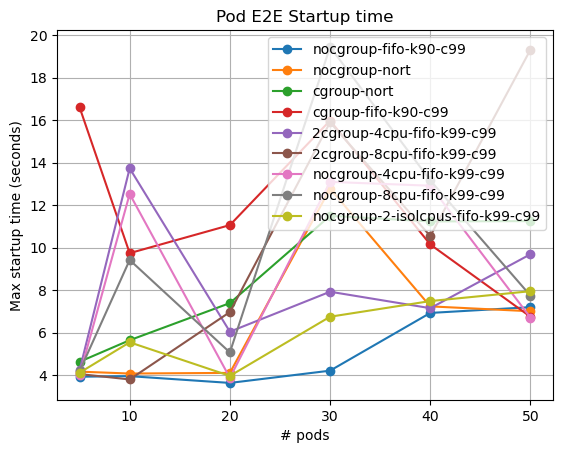

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

plt.title("Pod E2E Startup time")
plt.xlabel("# pods")
plt.ylabel("Max startup time (seconds)")

for (name, data) in results.items():
    plt.plot(xs[1:], [d.max().total_seconds() for d in data], label=name, marker="o")
    
plt.legend()
plt.grid(True)
plt.savefig("build/max.pdf")
plt.savefig("build/max.png")
plt.savefig("build/max.svg")

In [4]:
import matplotlib.pylab as plt
from scipy.stats import genextreme

import numpy as np
import pandas as pd

m = {name: pd.Index([d.max().total_seconds() for d in data]) for (name, data) in results.items()}
df = pd.DataFrame(m, index=xs[1:])

# Dictionary to store GEV parameters for each column
gev_params = {}

# Fit GEV distribution to each column of the DataFrame
for column in df.columns[:]:
    data = df[column].values
    c, loc, scale = genextreme.fit(data)
    gev_params[column] = (c, loc, scale)

gev_params

{'nocgroup-fifo-k90-c99': (-1.0483741606947397,
  3.9303076103854067,
  0.4601029980914835),
 'nocgroup-nort': (-9.519393299254606, 4.144390455999776, 0.7279999436457636),
 'cgroup-nort': (1.5413168385890053, 9.158813840363965, 3.6012639196603393),
 'cgroup-fifo-k90-c99': (0.25034613761752644,
  10.423773767185152,
  3.3023064204359445),
 '2cgroup-4cpu-fifo-k99-c99': (-0.022931751837219898,
  6.699726811286623,
  2.349666504993599),
 '2cgroup-8cpu-fifo-k99-c99': (-7.6860303959600955,
  4.061310990358687,
  2.087548948254292),
 'nocgroup-4cpu-fifo-k99-c99': (1.100670235456156,
  10.225080187364869,
  3.1581881218149492),
 'nocgroup-8cpu-fifo-k99-c99': (-0.4281392275237168,
  6.657872678390575,
  3.0686499604741764),
 'nocgroup-2-isolcpus-fifo-k99-c99': (1.078833677809167,
  6.326668692959284,
  1.7465349605879035)}

nocgroup-fifo-k90-c99 [3.917774 3.944487 3.625494 4.202663 6.921619 7.194302]
nocgroup-nort [ 4.157002  4.067915  4.098051 12.774584  7.230755  7.00049 ]
cgroup-nort [ 4.622578  5.636994  7.38518  11.495299 11.232021 11.246309]
cgroup-fifo-k90-c99 [16.607254  9.737329 11.058457 15.981572 10.145935  6.739469]
2cgroup-4cpu-fifo-k99-c99 [ 4.221681 13.731719  6.038383  7.920595  7.145079  9.686399]
2cgroup-8cpu-fifo-k99-c99 [ 4.043086  3.789708  6.962673 15.897681 10.543515 19.321431]
nocgroup-4cpu-fifo-k99-c99 [ 3.984296 12.52507   3.865049 13.094412 12.913107  6.700599]
nocgroup-8cpu-fifo-k99-c99 [ 4.177616  9.415724  5.060363 19.449883 13.163726  7.735402]
nocgroup-2-isolcpus-fifo-k99-c99 [4.106073 5.539106 3.956261 6.743538 7.48009  7.945579]


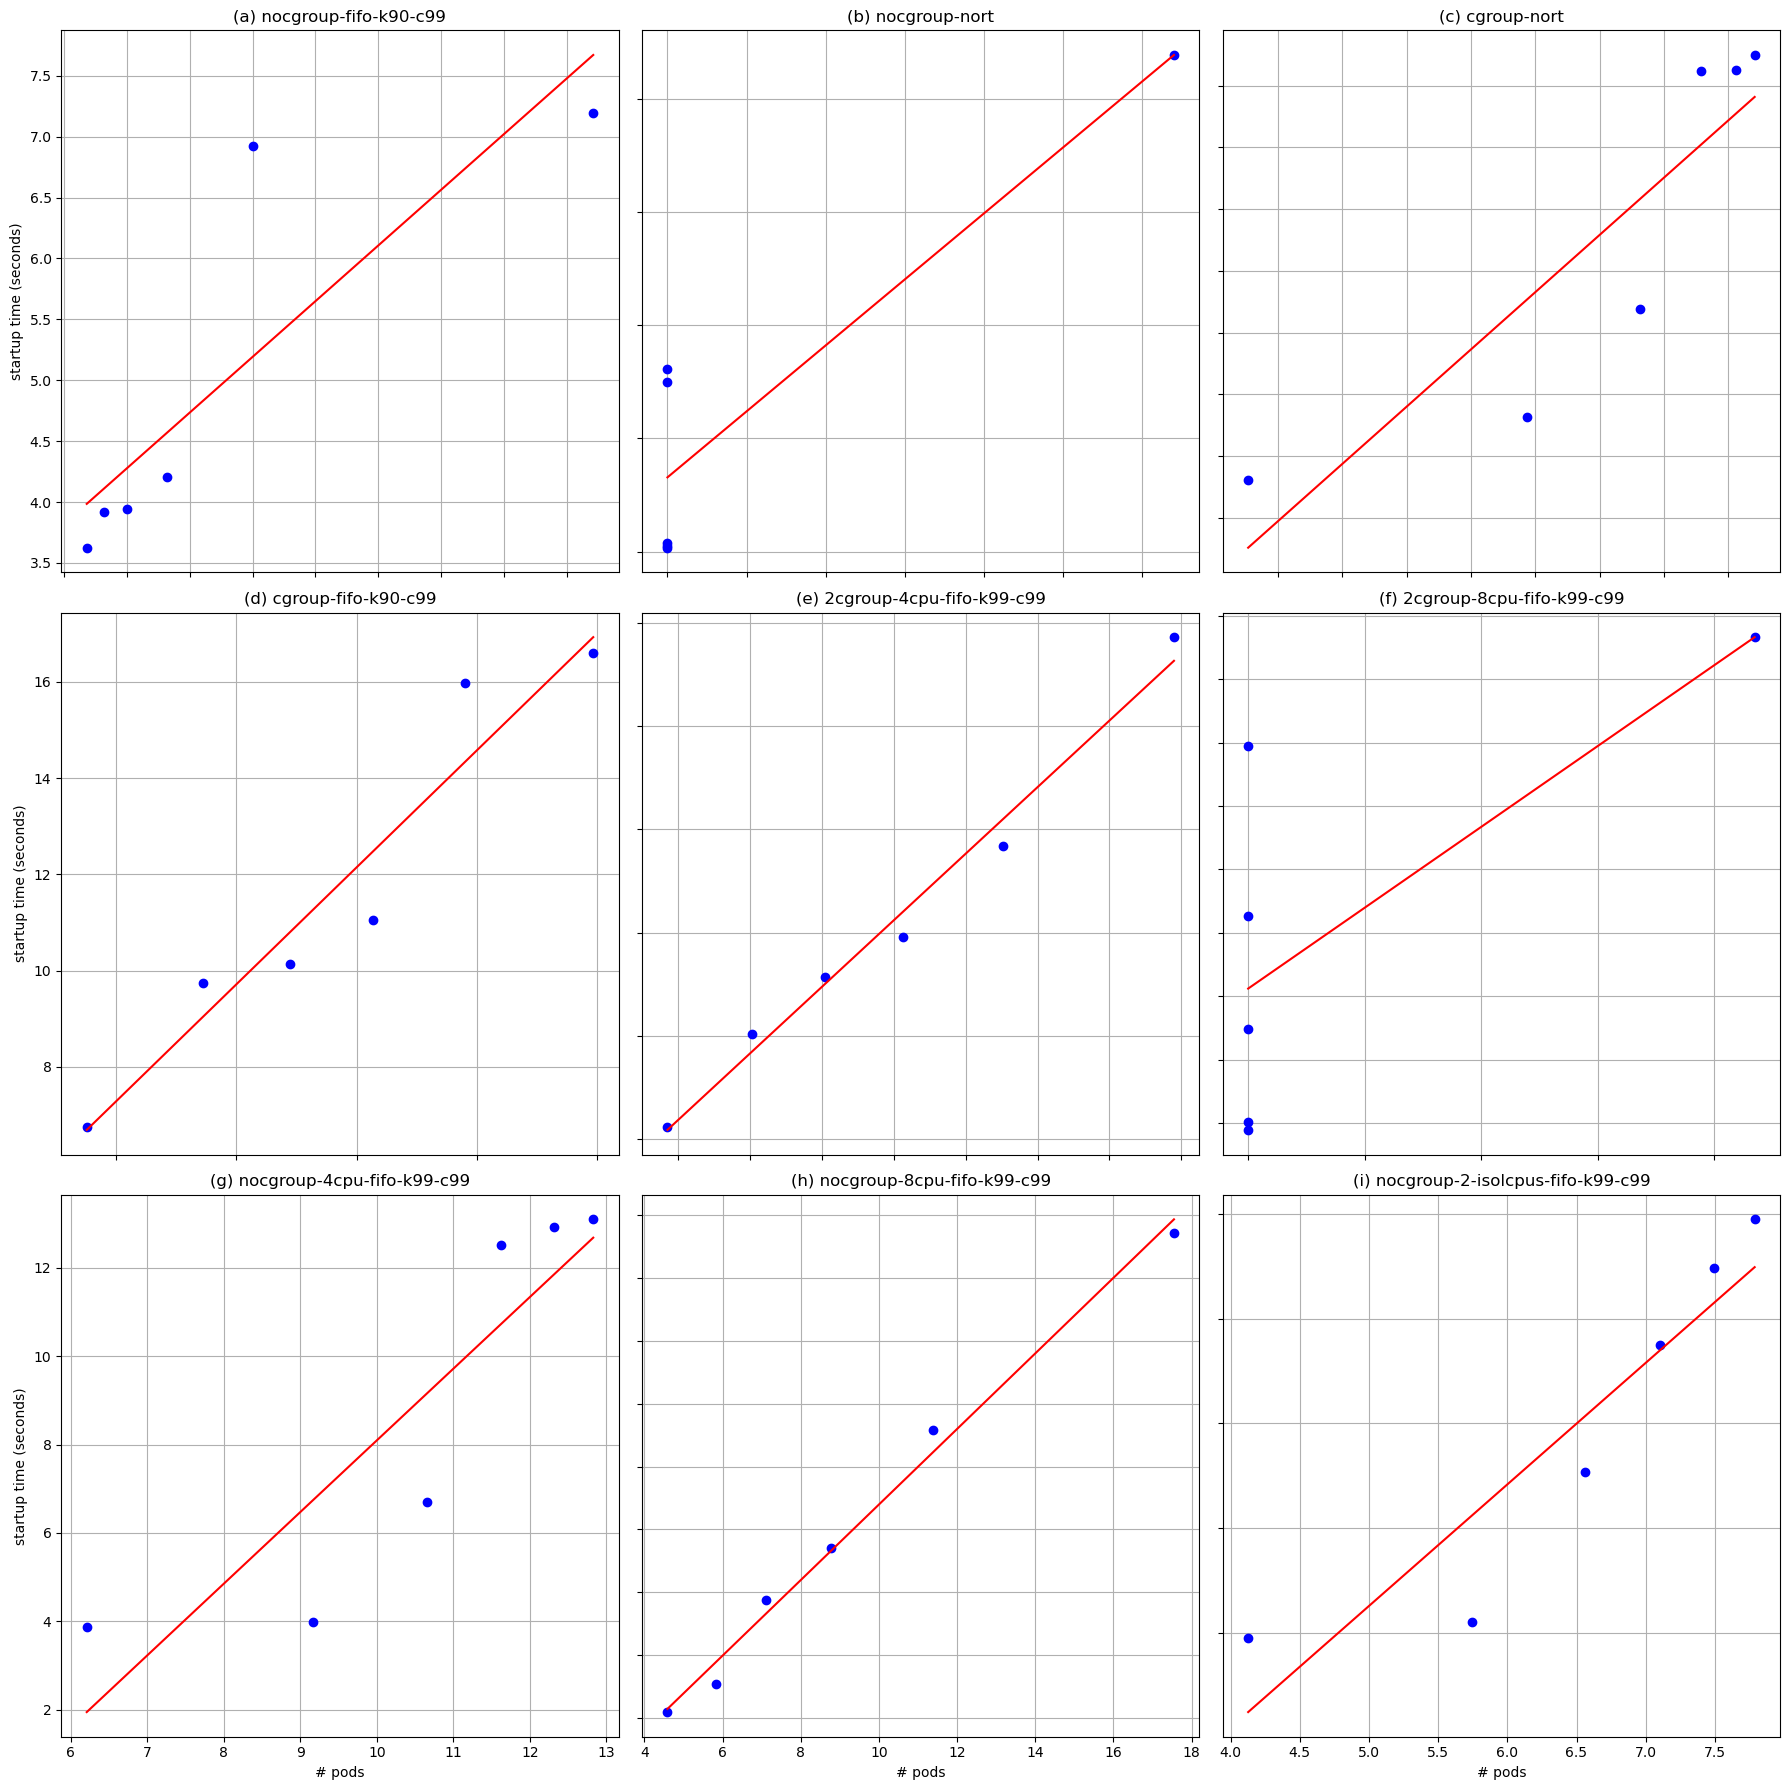

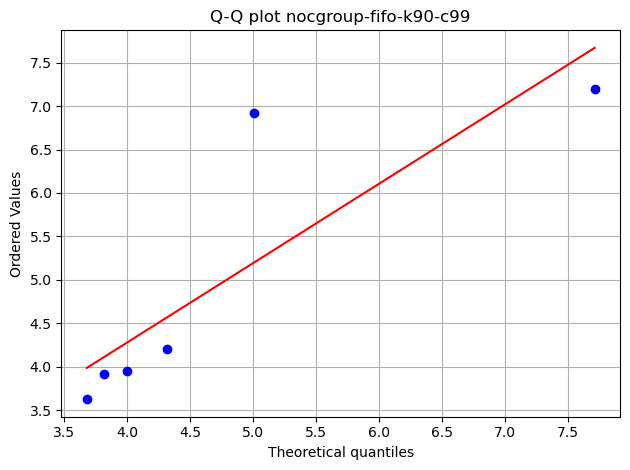

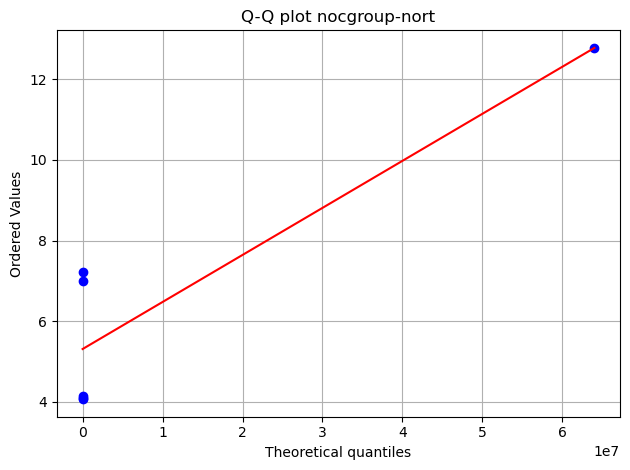

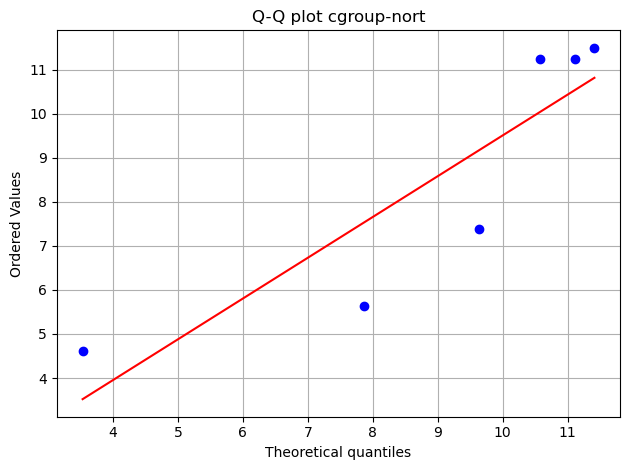

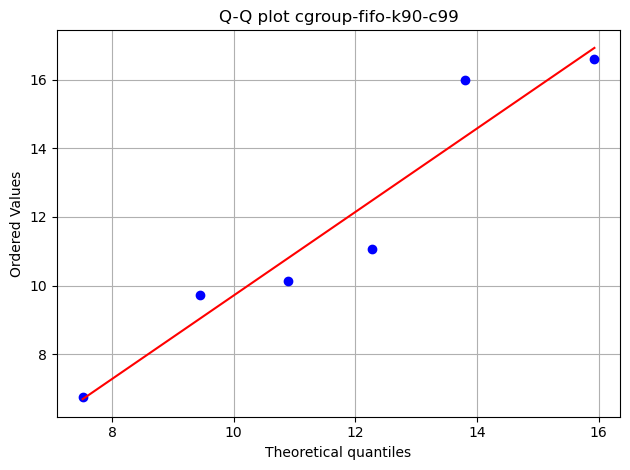

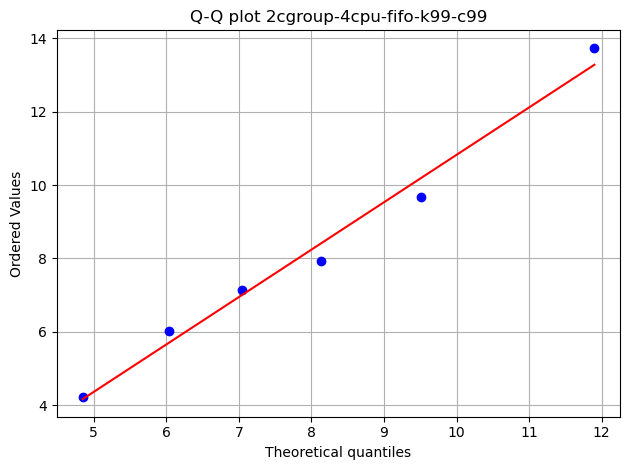

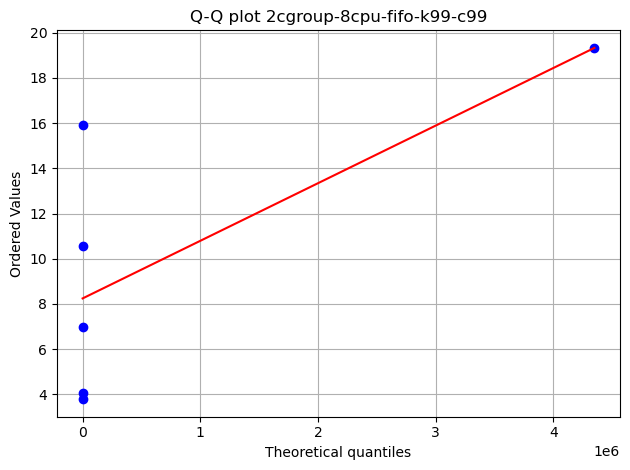

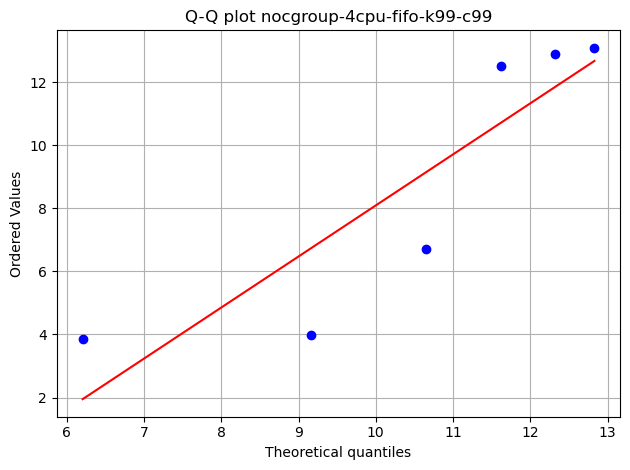

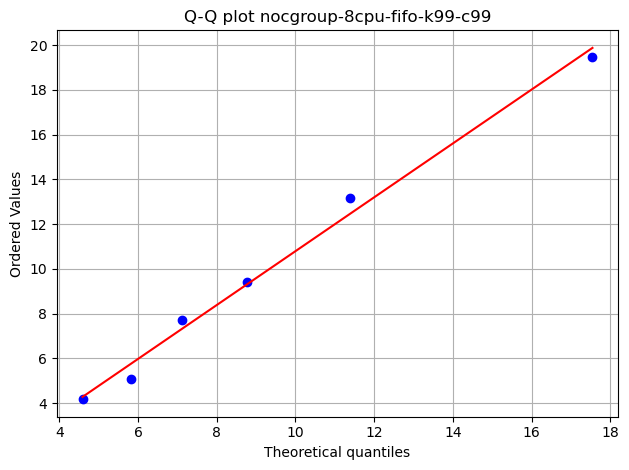

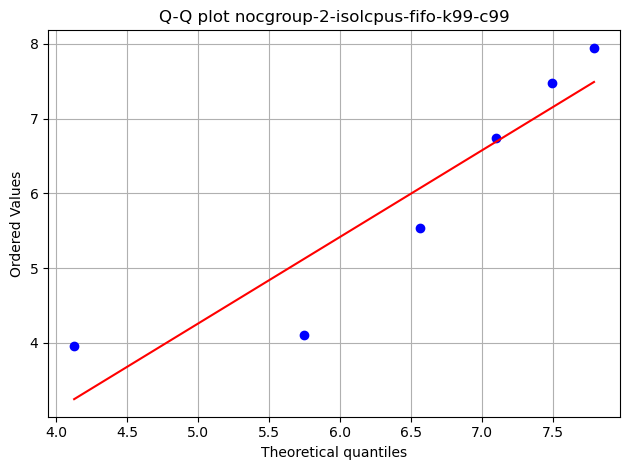

In [7]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create Q-Q plots for each column to validate GEV fit
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 18))
axes = axes.flatten()

for i, column in enumerate(df.columns[:]):
    data = df[column].values
    print(column, data)
    c, loc, scale = gev_params[column]
    
    # Generate Q-Q plot
    stats.probplot(data, dist="genextreme", sparams=(c, loc, scale), plot=axes[i])
    
    axes[i].set_title(f"({chr(i + 97)}) {column}")
    axes[i].grid(True)
    #axes[i].set_ylim([0, 20])

    
for ax in axes.flat:
        ax.set(xlabel='# pods', ylabel='startup time (seconds)')
    
# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axes.flat:
        ax.label_outer()

plt.tight_layout()
plt.show()
fig.savefig("build/qqplot.pdf")
fig.savefig("build/qqplot.png")
fig.savefig("build/qqplot.svg")

for i, column in enumerate(df.columns[:]):
    data = df[column].values
    c, loc, scale = gev_params[column]

    ax = plt.gca()
    # Generate Q-Q plot
    stats.probplot(data, dist="genextreme", sparams=(c, loc, scale), plot=plt)
    
    plt.title(f"Q-Q plot {column}")
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig(f"build/qqplot-{column}.pdf")
    plt.savefig(f"build/qqplot-{column}.png")
    plt.savefig(f"build/qqplot-{column}.svg")
    # ax.set_ylim([0, 20])
    plt.show()


In [158]:
import matplotlib.pyplot as plt
import numpy as np

iqrs = [None] * len(xs[1:])
for (i, v) in enumerate(xs[1:]):
    iqrs[i] = {}
    for experiment in experiments:
        name = experiment["name"]
        data = results[name][i]
        data = [d.total_seconds() for d in data]
        q75, q25 = np.percentile(data, [75 ,25])
        iqr = q75 - q25
        iqrs[i][name] = iqr

for (i, iqr) in enumerate(iqrs):
    values = iqr.values()
    reduction = (max(values) - min(values)) / abs(max(values))
    print(xs[1:][i], "pods", f"{reduction*100}%", "inter quartile reduction")

5 pods 66.41528939936087% inter quartile reduction
10 pods 55.01726121979288% inter quartile reduction
20 pods 68.79456780996136% inter quartile reduction
30 pods 79.13258749145007% inter quartile reduction
40 pods 77.07347818020179% inter quartile reduction
50 pods 79.00955041406668% inter quartile reduction


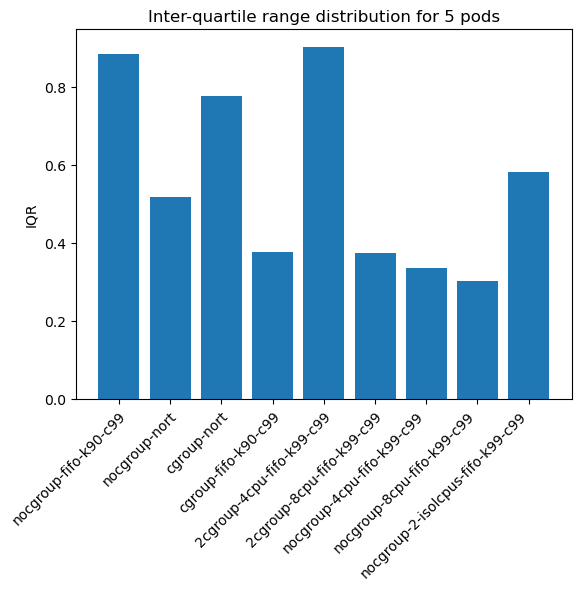

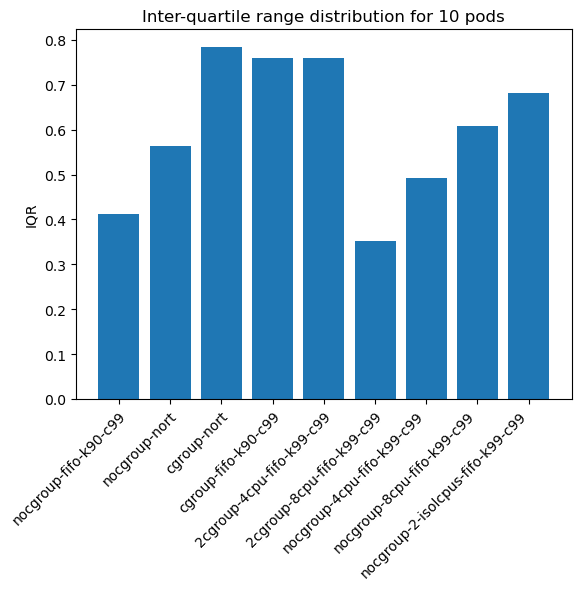

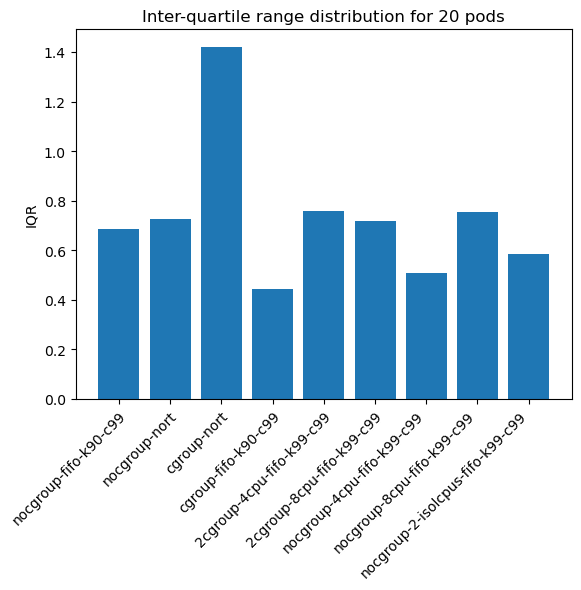

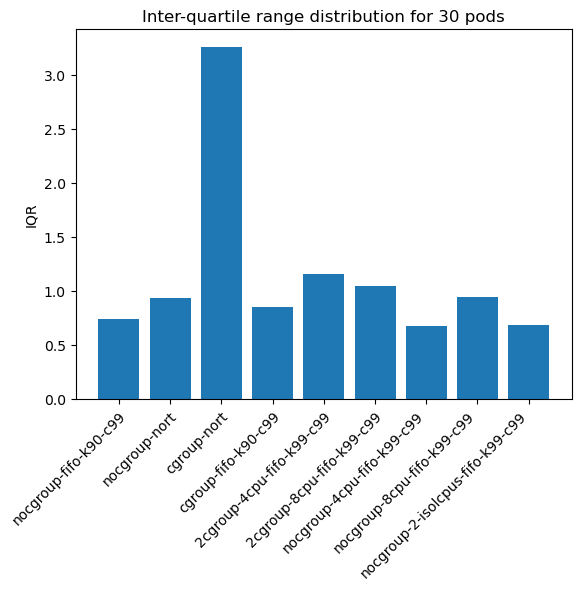

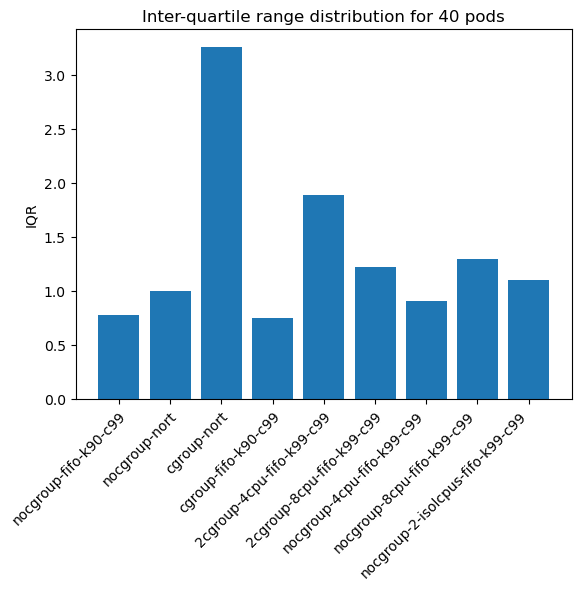

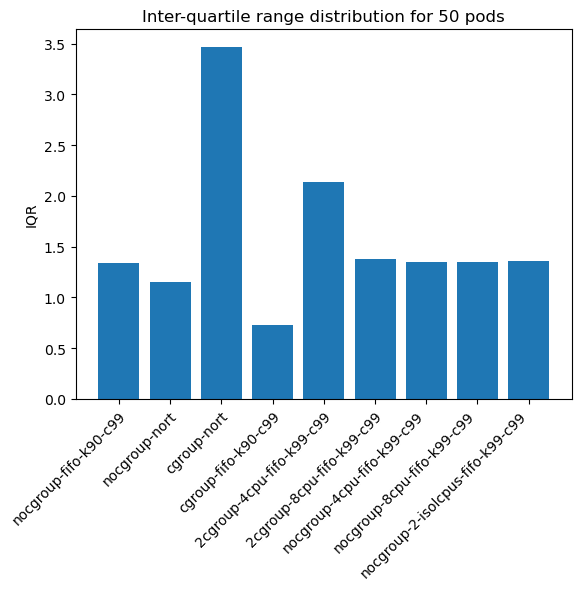

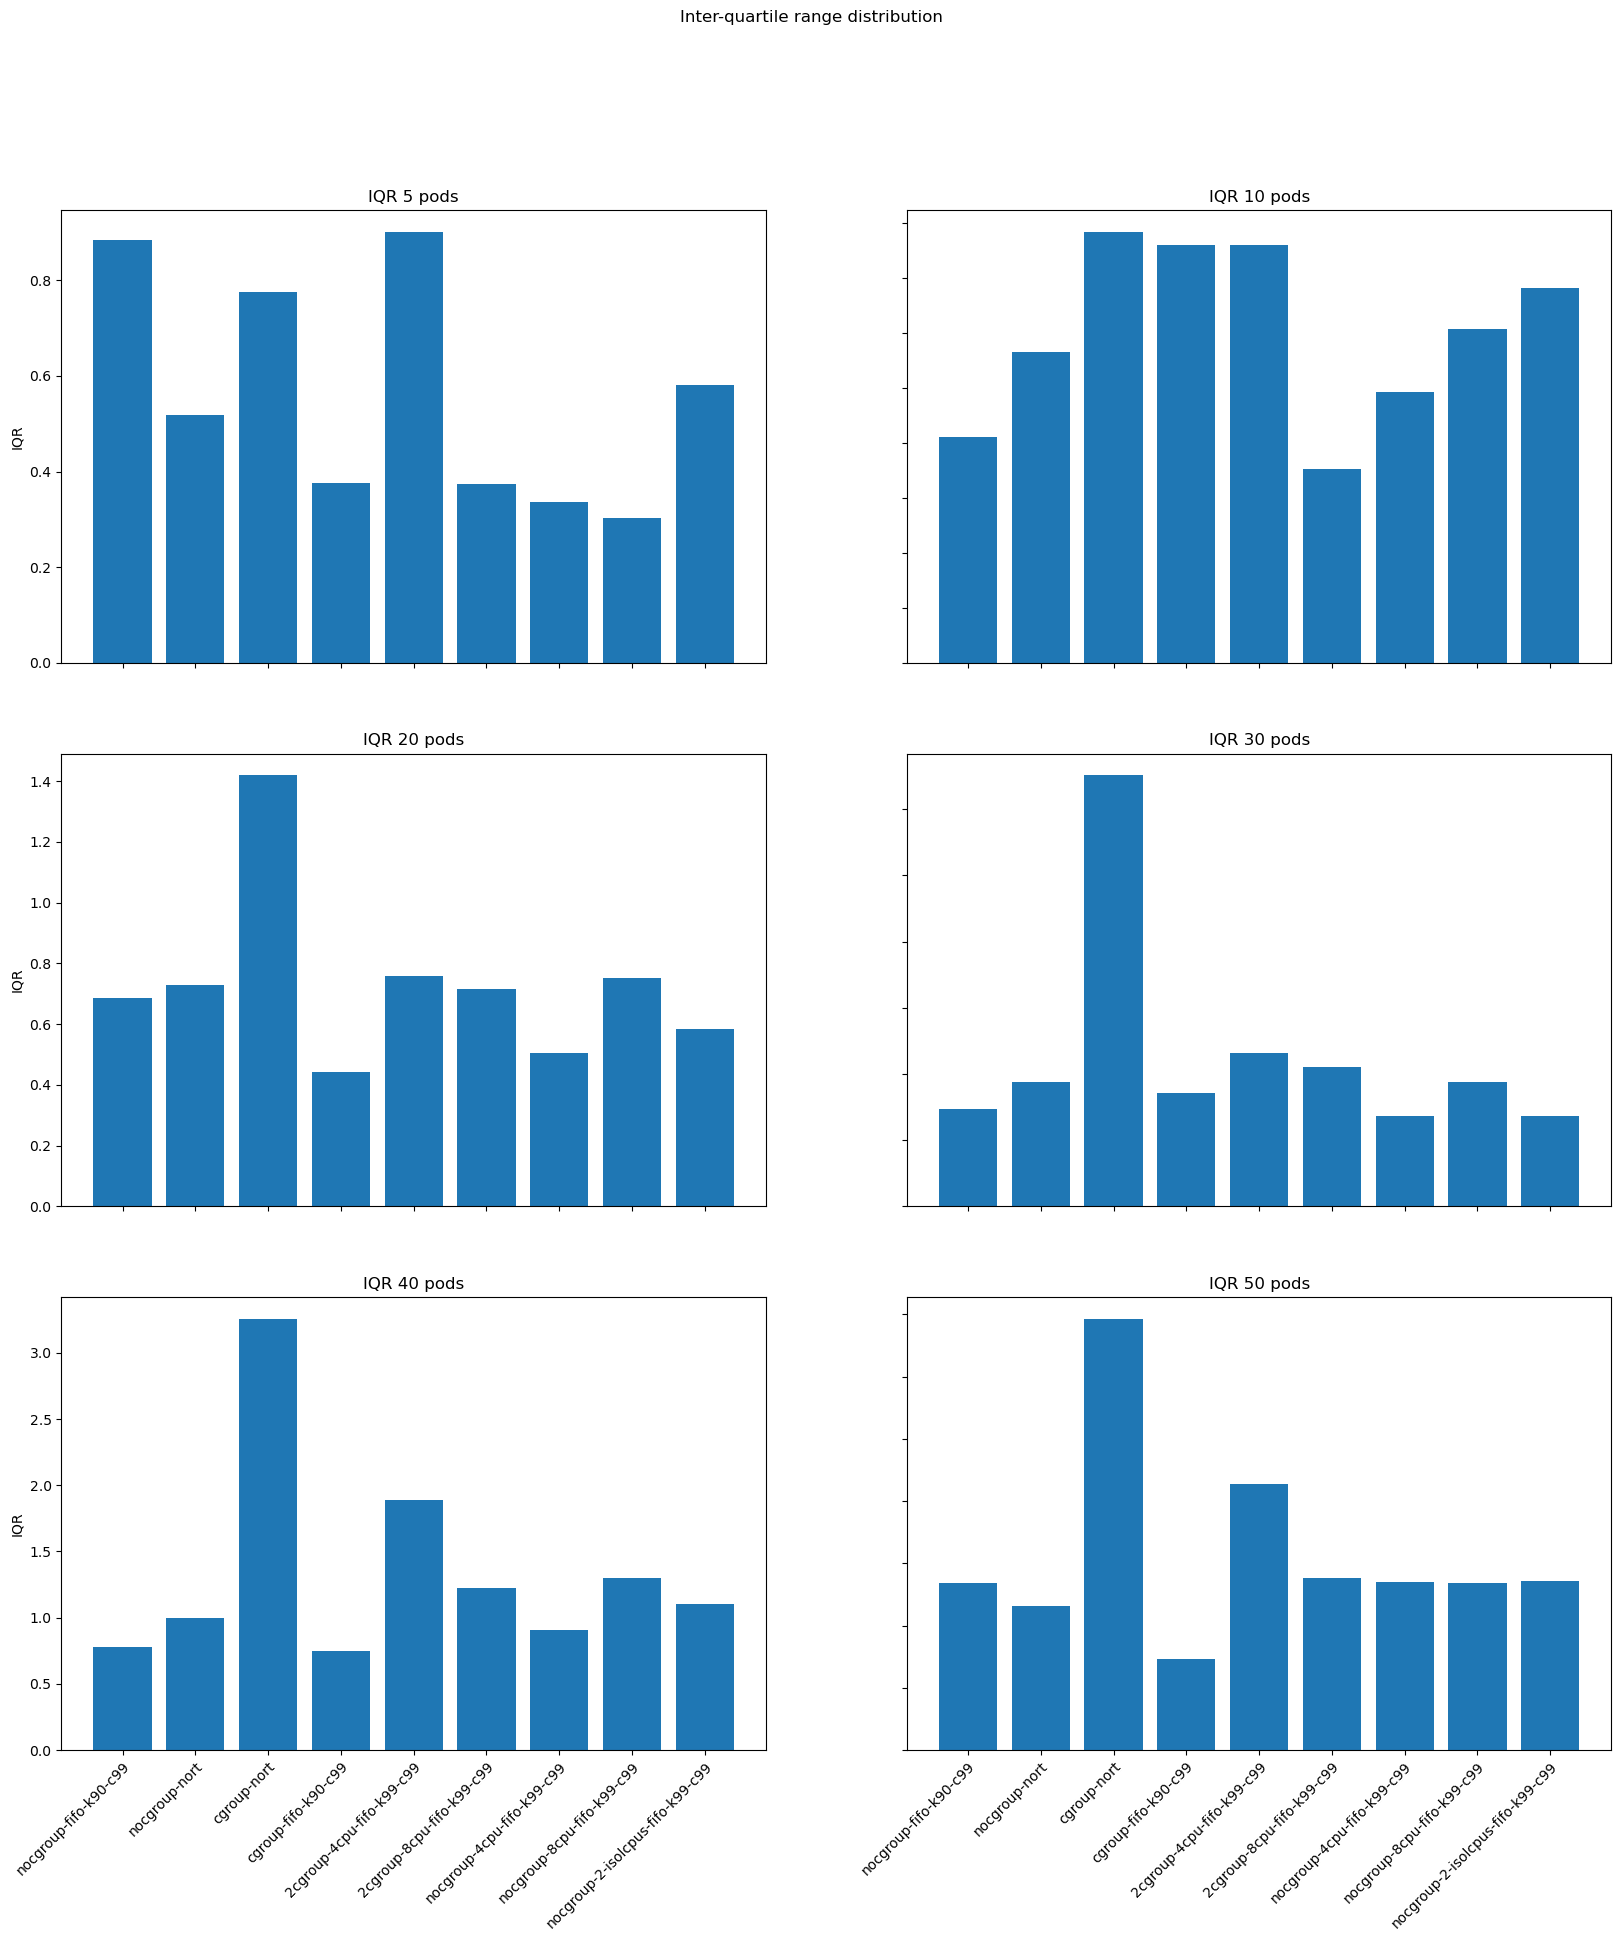

In [159]:
for (i, n) in enumerate(xs[1:]):
    plt.title(f"Inter-quartile range distribution for {n} pods")
    plt.ylabel("IQR")
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
    plt.bar(iqrs[i].keys(), iqrs[i].values(), color="tab:blue")
    plt.savefig(f"build/iqr-{n}-pods.pdf", dpi=300, bbox_inches = "tight")
    plt.savefig(f"build/iqr-{n}-pods.png", dpi=300, bbox_inches = "tight")
    plt.savefig(f"build/iqr-{n}-pods.svg", dpi=300, bbox_inches = "tight")
    plt.show()

rows = 3
cols = 2

def iqr_all_quick(odir: str) -> None:
    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Inter-quartile range distribution")
    axs = fig.subplots(rows, cols)

    for i in range(rows):
        for j in range(cols):
            k = i*cols+j
            ax = axs[i, j]
            pods = xs[1:][k]
            ax.set_xticks(range(len(iqrs[k].keys())), rotation=45, ha="right", rotation_mode="anchor", labels=iqrs[k].keys())
            ax.bar(iqrs[k].keys(), iqrs[k].values(), color="tab:blue")
            ax.set_title(f"IQR {pods} pods")

    for ax in axs.flat:
        ax.set(ylabel='IQR')
    
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
        
    if odir is not None:
        p = os.path.join(odir, "iqr.pdf")
        fig.savefig(p)
        p = os.path.join(odir, "iqr.png")
        fig.savefig(p)
        p = os.path.join(odir, "iqr.svg")
        fig.savefig(p)

iqr_all_quick("build")

In [4]:
import numpy as np
import pandas as pd

devs = [None] * len(xs[1:])
for (i, v) in enumerate(xs[1:]):
    devs[i] = {}
    for experiment in experiments:
        name = experiment["name"]
        data = results[name][i]
        data = [d.total_seconds() for d in data]
        devs[i][name] = np.var(data)

for (i, dev) in enumerate(devs):
    values = dev.values()
    reduction = (max(values) - min(values)) / abs(max(values))
    print(xs[1:][i], "pods", f"{reduction*100}%", "variance reduction")

TypeError: unsupported operand type(s) for /: 'dict_values' and 'int'

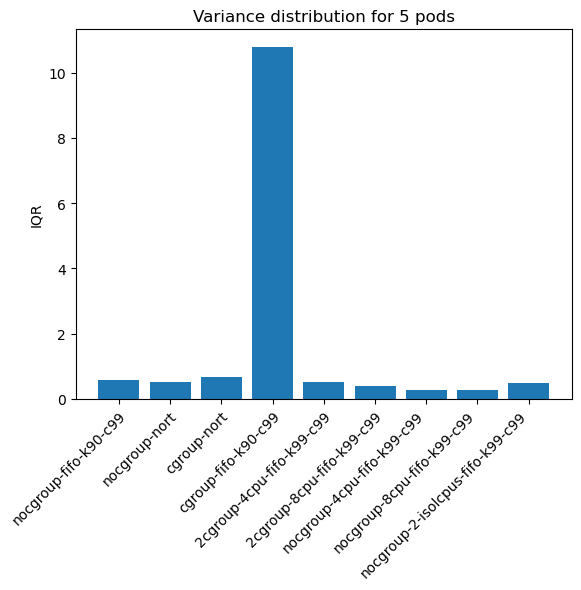

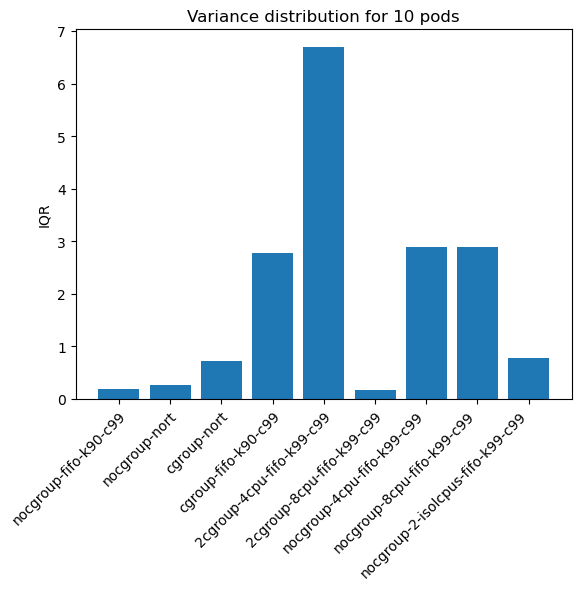

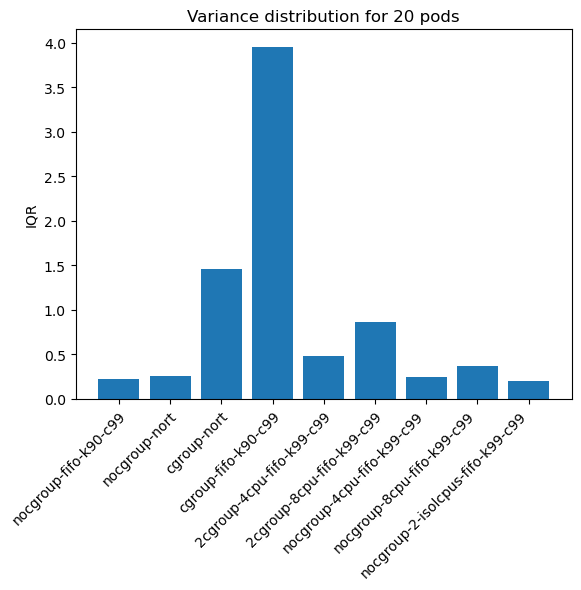

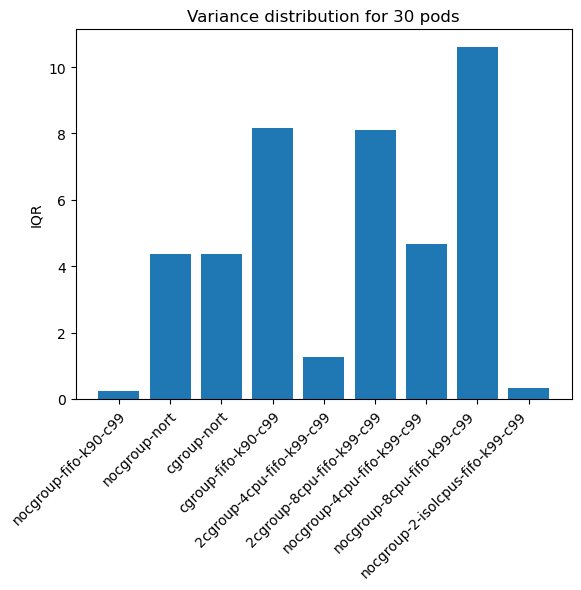

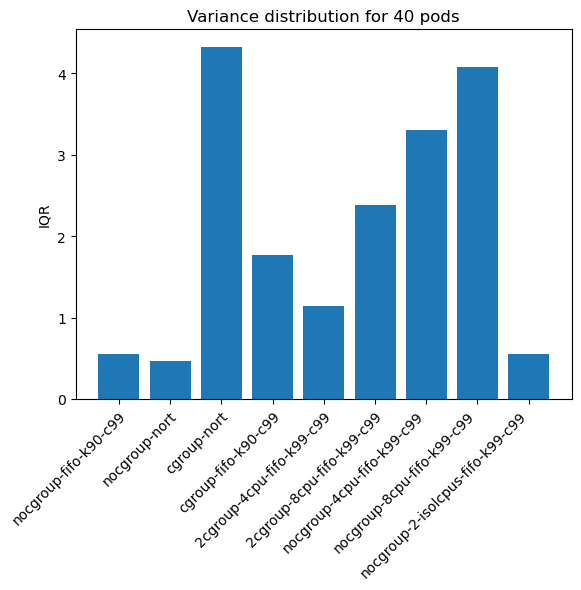

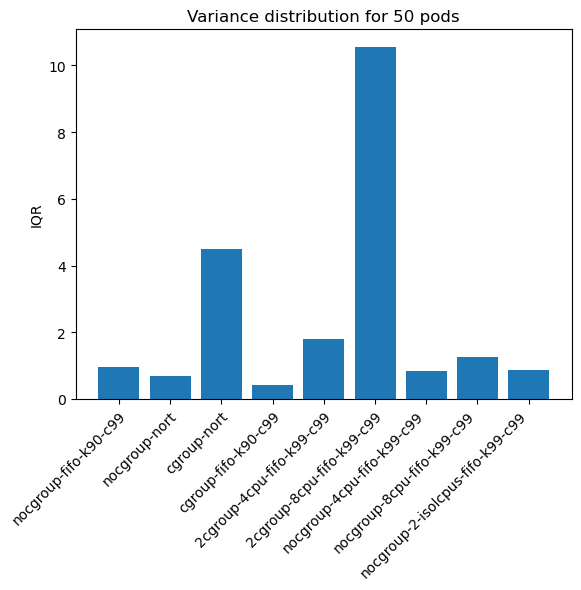

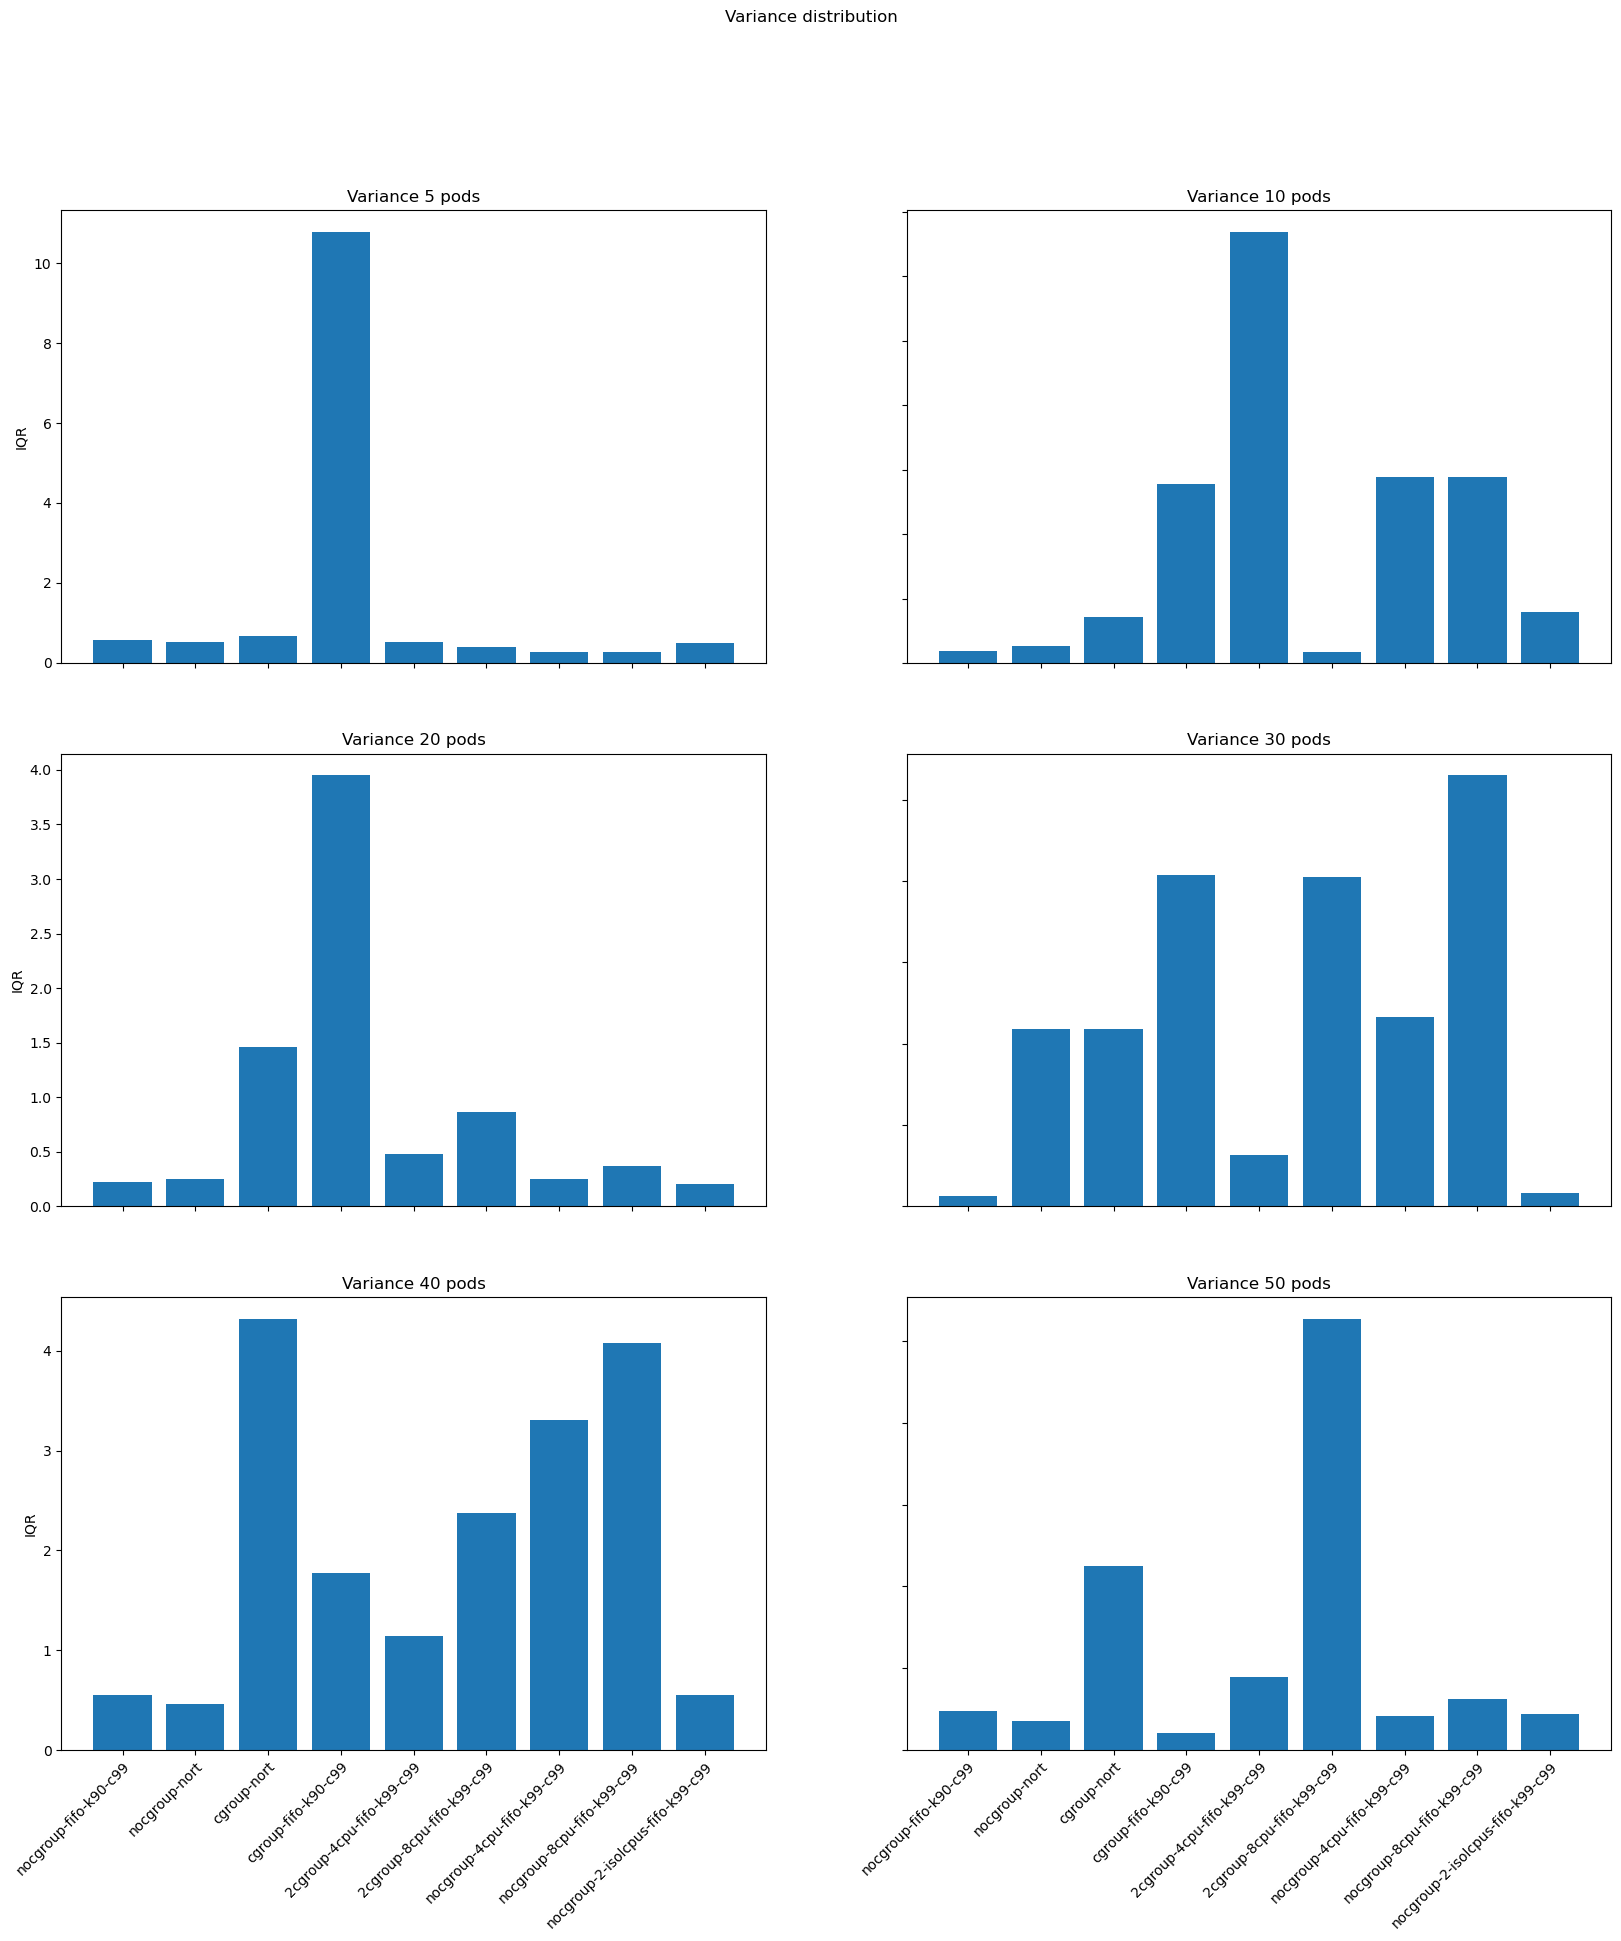

In [161]:
for (i, n) in enumerate(xs[1:]):
    plt.title(f"Variance distribution for {n} pods")
    plt.ylabel("IQR")
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
    plt.bar(devs[i].keys(), devs[i].values(), color="tab:blue")
    plt.savefig(f"build/variance-{n}-pods.pdf", dpi=300, bbox_inches = "tight")
    plt.savefig(f"build/variance-{n}-pods.png", dpi=300, bbox_inches = "tight")
    plt.savefig(f"build/variance-{n}-pods.svg", dpi=300, bbox_inches = "tight")
    plt.show()

def std_all_quick(odir: str) -> None:
    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Variance distribution")
    axs = fig.subplots(rows, cols)

    for i in range(rows):
        for j in range(cols):
            k = i*cols+j
            ax = axs[i, j]
            pods = xs[1:][k]
            ax.set_xticks(range(len(devs[k].keys())), rotation=45, ha="right", rotation_mode="anchor", labels=devs[k].keys())
            ax.bar(devs[k].keys(), devs[k].values(), color="tab:blue")
            ax.set_title(f"Variance {pods} pods")

    for ax in axs.flat:
        ax.set(ylabel='IQR')
    
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
        
    if odir is not None:
        p = os.path.join(odir, "variance.pdf")
        fig.savefig(p)
        p = os.path.join(odir, "variance.png")
        fig.savefig(p)
        p = os.path.join(odir, "variance.svg")
        fig.savefig(p)

std_all_quick("build")

cgroup-fifo-k90-c99 [16.607254  9.737329 11.058457 15.981572 10.145935  6.739469]


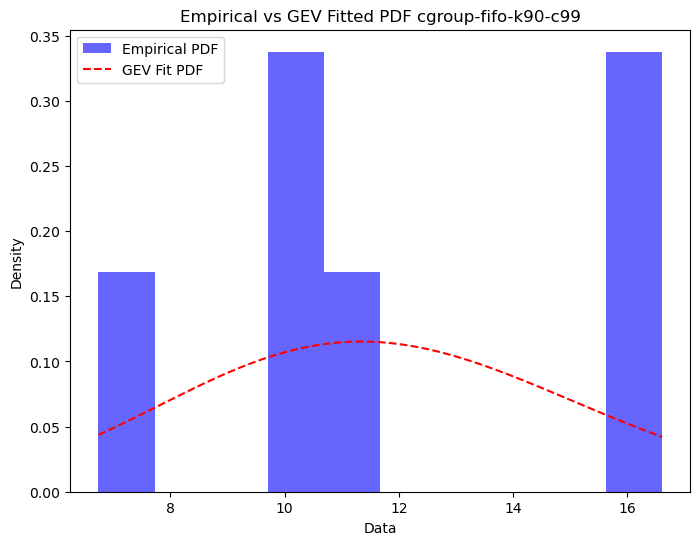

nocgroup-2-isolcpus-fifo-k99-c99 [4.106073 5.539106 3.956261 6.743538 7.48009  7.945579]


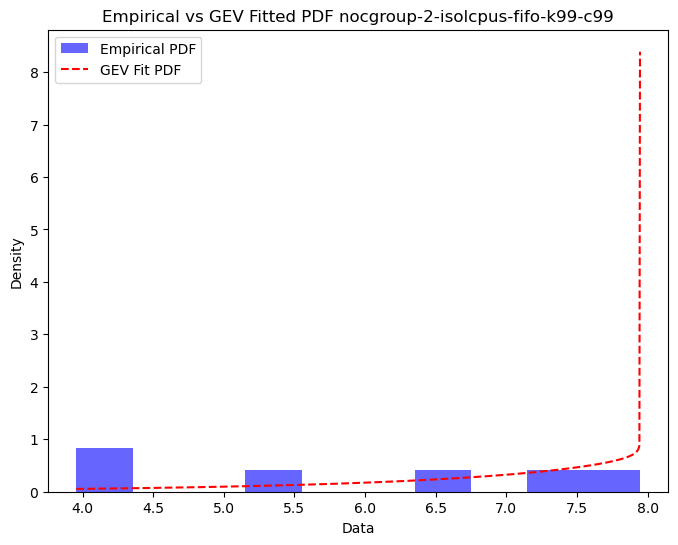

nocgroup-8cpu-fifo-k99-c99 [ 4.177616  9.415724  5.060363 19.449883 13.163726  7.735402]


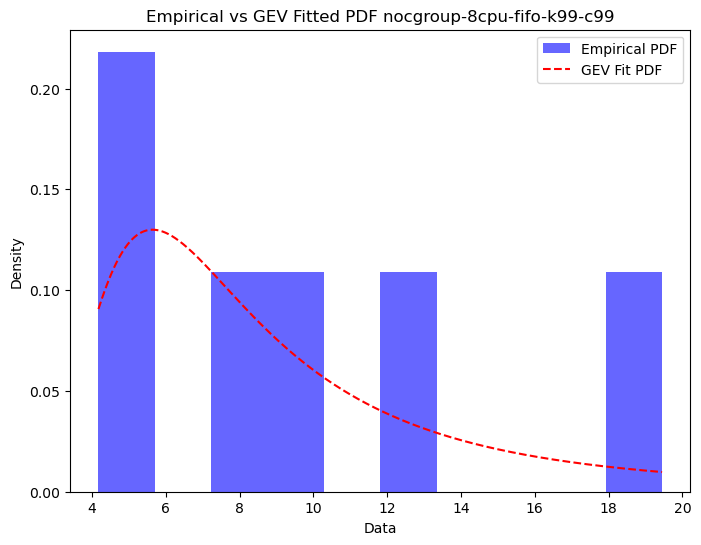

2cgroup-4cpu-fifo-k99-c99 [ 4.221681 13.731719  6.038383  7.920595  7.145079  9.686399]


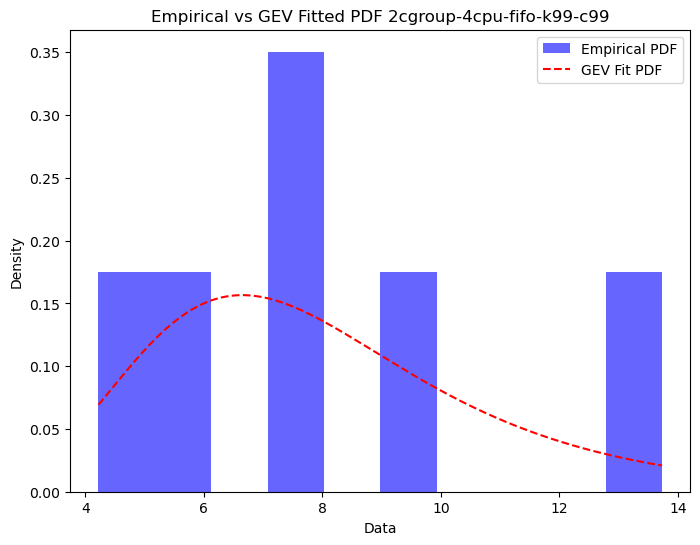

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

for column in ["cgroup-fifo-k90-c99", "nocgroup-2-isolcpus-fifo-k99-c99", "nocgroup-8cpu-fifo-k99-c99", "2cgroup-4cpu-fifo-k99-c99"]:
    
    c, loc, scale = gev_params[column]
    
    sample_data = df[column].values

    print(column, sample_data)
    
    # Create a range of values for the PDF
    x = np.linspace(min(sample_data), max(sample_data), 1000)
    
    # Calculate the GEV PDF
    gev_pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    
    # Plot the empirical PDF using a histogram or KDE
    plt.figure(figsize=(8, 6))
    
    # Option 1: Histogram with density=True to normalize (approximate PDF)
    plt.hist(sample_data, density=True, alpha=0.6, color='blue', label='Empirical PDF')
    
    # Plot the GEV PDF
    plt.plot(x, gev_pdf, label='GEV Fit PDF', color='red', linestyle='--')
    
    # Add labels and legend
    plt.xlabel('Data')
    plt.ylabel('Density')
    plt.title(f'Empirical vs GEV Fitted PDF {column}')
    plt.legend()
    
    # Show the plot
    plt.show()
